In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, ttest_ind

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder 
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)



In [55]:
main_df = pd.read_csv('/Users/jaydipchauhan/Documents/DS/Projects/Titanic/train.csv')

In [56]:
main_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [57]:
df_clean = main_df.copy()

In [58]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [59]:
df_clean.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [60]:
missing_percentage = df_clean.isnull().mean() * 100

missing_percentage

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [61]:
df_clean.groupby('Pclass')['Age'].median()

Pclass
1    37.0
2    29.0
3    24.0
Name: Age, dtype: float64

In [62]:
df_clean.groupby('Sex')['Age'].median()

Sex
female    27.0
male      29.0
Name: Age, dtype: float64

In [63]:
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())

In [64]:
df_clean[df_clean['Cabin'].isna()].head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,NaN,Q
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S


In [65]:
df_clean['CabinKnown'] = df_clean['Cabin'].notna().astype(int)

In [66]:
df_clean.groupby('CabinKnown')['Survived'].mean()

CabinKnown
0    0.299854
1    0.666667
Name: Survived, dtype: float64

In [67]:
df_clean.groupby(['Pclass','CabinKnown'])['Survived'].mean()

Pclass  CabinKnown
1       0             0.475000
        1             0.664773
2       0             0.440476
        1             0.812500
3       0             0.235908
        1             0.500000
Name: Survived, dtype: float64

In [68]:
df_clean['CabinKnown'].value_counts()

CabinKnown
0    687
1    204
Name: count, dtype: int64

In [69]:
df_clean.groupby('CabinKnown')['Survived'].mean()

CabinKnown
0    0.299854
1    0.666667
Name: Survived, dtype: float64

In [70]:
df_clean[df_clean['Embarked'].isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,CabinKnown
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN,1
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN,1


In [71]:
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])

In [72]:
df_clean.duplicated().sum()

np.int64(0)

In [73]:
survival_rate = df_clean['Survived'].mean()

print(f'Overall Survival Rate: {survival_rate:.2%}')

Overall Survival Rate: 38.38%


In [74]:
df_clean.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

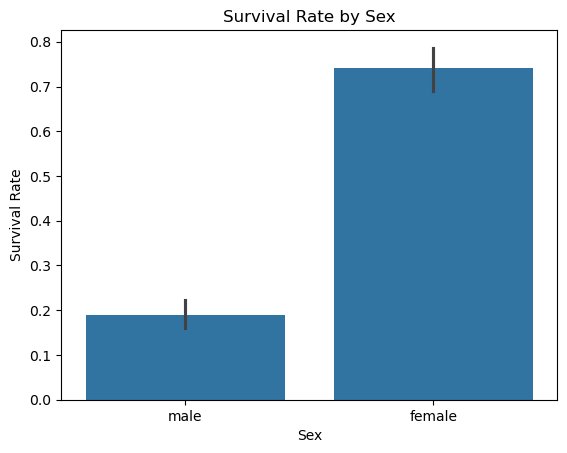

In [75]:
sns.barplot(data=df_clean, x='Sex', y='Survived')
plt.title('Survival Rate by Sex')
plt.ylabel('Survival Rate')
plt.show()

In [76]:
df_clean.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

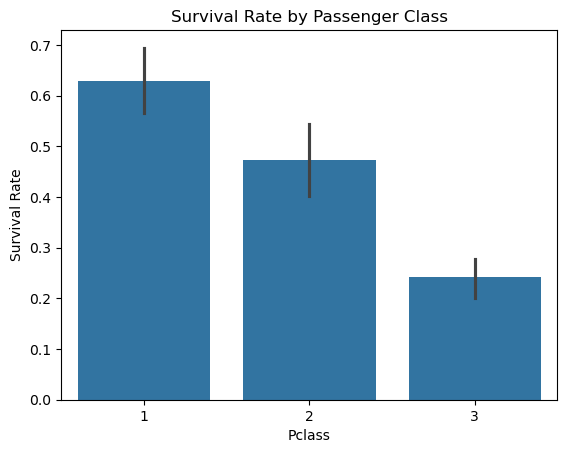

In [77]:
sns.barplot(data=df_clean, x='Pclass', y='Survived')
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

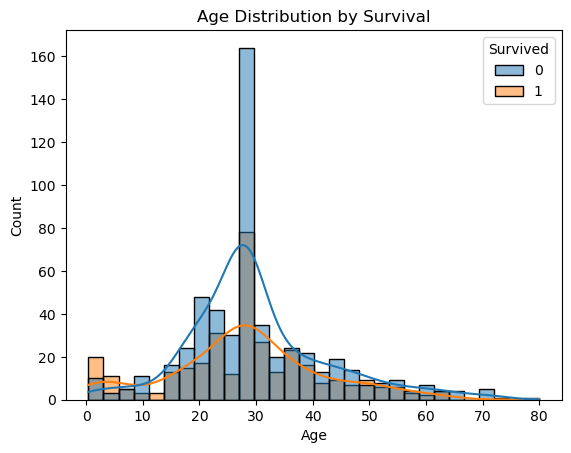

In [78]:
sns.histplot(
    data=df_clean, x='Age', hue='Survived', bins=30, kde=True)

plt.title('Age Distribution by Survival')
plt.show()

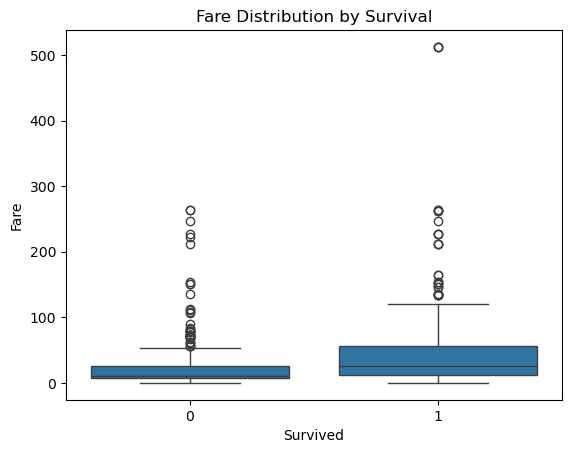

In [79]:
sns.boxplot(data=df_clean, x='Survived', y='Fare')

plt.title('Fare Distribution by Survival')
plt.show()

In [80]:
df_clean.groupby('Embarked')['Survived'].mean()

Embarked
C    0.553571
Q    0.389610
S    0.339009
Name: Survived, dtype: float64

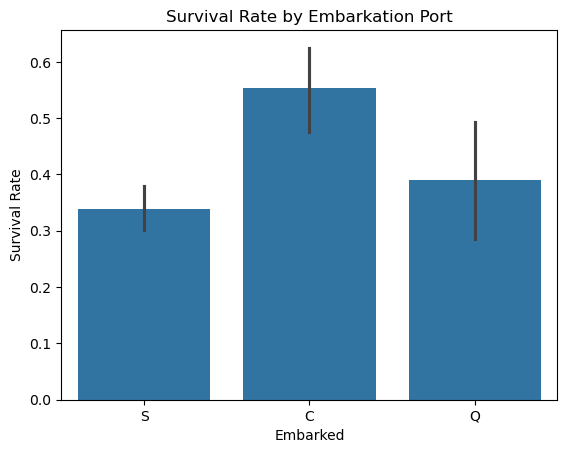

In [81]:
sns.barplot(data=df_clean, x='Embarked', y='Survived')

plt.title('Survival Rate by Embarkation Port')
plt.ylabel('Survival Rate')
plt.show()

In [82]:
df_clean[['SibSp', 'Parch']].sample(10)

,SibSp,Parch
103,0,0
688,0,0
447,0,0
377,0,2
55,0,0
441,0,0
402,1,0
594,1,0
273,0,1
725,0,0


In [83]:
df_clean['FamilySize'] = df_clean['SibSp'] + df_clean['Parch'] + 1

In [84]:
df_clean[['SibSp', 'Parch', 'FamilySize']].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


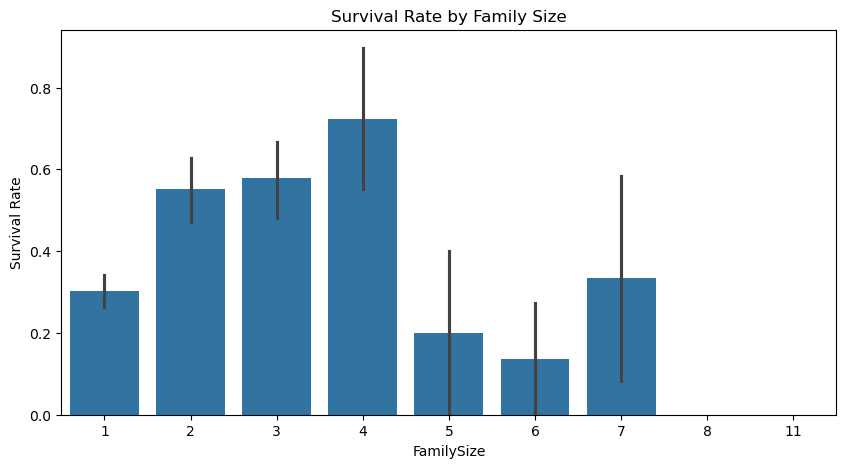

In [85]:
plt.figure(figsize=(10,5))

sns.barplot(data=df_clean, x='FamilySize', y='Survived')

plt.title('Survival Rate by Family Size')
plt.ylabel('Survival Rate')
plt.show()

In [86]:
df_clean['IsAlone'] = (df_clean['FamilySize'] == 1).astype(int)

In [87]:
df_clean.groupby('IsAlone')['Survived'].mean()

IsAlone
0    0.505650
1    0.303538
Name: Survived, dtype: float64

In [88]:
cont_table = pd.crosstab(
    df_clean['Sex'], df_clean['Survived']
)

chi2, p, dof, expected = chi2_contingency(cont_table)

print('Chi-square statistics:', chi2)
print('p-value:', p)

Chi-square statistics: 260.71702016732104
p-value: 1.197357062775565e-58


In [89]:
features = [
    'Pclass',
    'Sex',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'Embarked',
    'CabinKnown',
    'FamilySize',
    'IsAlone'
    ]

X = df_clean[features]
y = df_clean['Survived']


In [90]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [91]:
cat_features = [
    'Sex',
    'Embarked'
]

In [92]:
num_features = [
    'Pclass',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'CabinKnown',
    'FamilySize',
    'IsAlone'
]

In [93]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
                ]),
            num_features
        ),
        (
            'cat', 
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')), 
                ('onehot', OneHotEncoder(handle_unknown='ignore'))
                ]),
            cat_features
            )
    ]
)


In [94]:
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [95]:
logistic_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

logistic_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [96]:
y_pred_logistic = logistic_model.predict(X_test)

In [97]:
accuracy_logistic = accuracy_score(
    y_test, y_pred_logistic
)

print('logistic Regression Accuracy:',f'{accuracy_logistic:.2%}')

print(classification_report(
    y_test,
    y_pred_logistic
))

logistic Regression Accuracy: 80.45%
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       110
           1       0.76      0.72      0.74        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [98]:
random_forest = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        max_depth=6
    ))
])

random_forest.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [99]:
y_pred_rf = random_forest.predict(X_test)

In [100]:
accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)

print('Random Forest Accuracy:', f'{accuracy_rf:.2%}')

print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 80.45%
              precision    recall  f1-score   support

           0       0.80      0.92      0.85       110
           1       0.83      0.62      0.71        69

    accuracy                           0.80       179
   macro avg       0.81      0.77      0.78       179
weighted avg       0.81      0.80      0.80       179



In [101]:
results = pd.DataFrame({
    'Model' : [
        'Logistic Regression',
        'Random Forest'
    ],
    'Accuracy' : [
        accuracy_logistic,
        accuracy_rf
    ]
})

results.round(3)

,Model,Accuracy
0,Logistic Regression,0.804
1,Random Forest,0.804


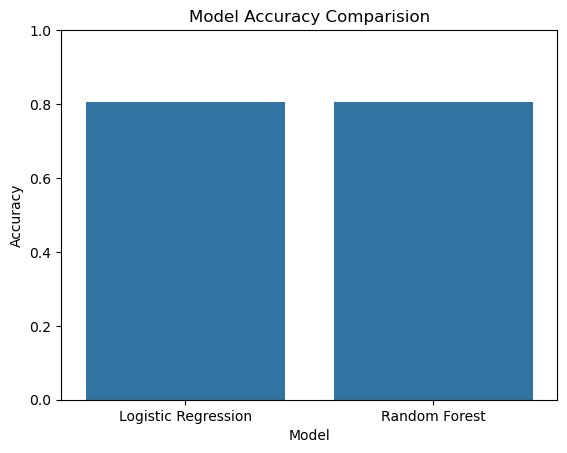

In [102]:
sns.barplot(
    data=results,
    x='Model',
    y='Accuracy'
)

plt.title('Model Accuracy Comparision')
plt.ylim(0,1)

plt.show()

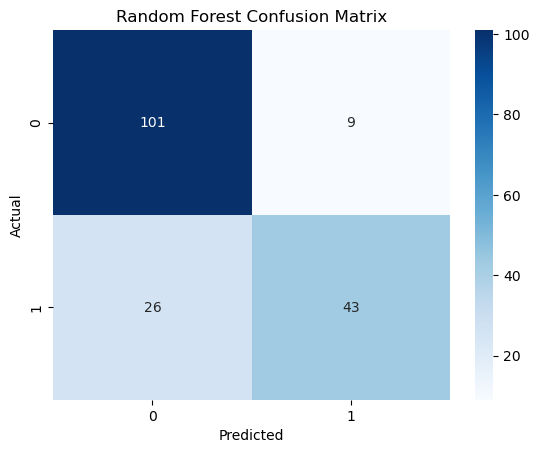

In [103]:
cm = confusion_matrix(
    y_test,
    y_pred_rf
)

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues'
)

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [104]:
y_prob = random_forest.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print(f'ROC-AUC Score: {roc_auc:.3f}')

ROC-AUC Score: 0.838


In [106]:
import joblib 

joblib.dump(logistic_model, 'titanic_model.pkl')

['titanic_model.pkl']